In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchsummary import summary
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'You have {device} {torch.cuda.get_device_name()} available on your machine and ready to be used for training')
print(f'GPU index is: {torch.cuda.current_device()}')

You have cuda NVIDIA GeForce RTX 4060 Laptop GPU available on your machine and ready to be used for training
GPU index is: 0


In [3]:
dataUrl = 'https://www.kaggle.com/datasets/mssmartypants/rice-type-classification'
import opendatasets as od 
od.download(dataUrl)

Skipping, found downloaded files in ".\rice-type-classification" (use force=True to force download)


# Exploratory Analysis

In [4]:
dataPath = 'rice-type-classification/riceClassification.csv'
df = pd.read_csv(dataPath)
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [5]:
df.drop('id',inplace=True,axis=1)
df.shape

(18185, 11)

In [6]:
df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')

In [7]:
df.dtypes

Area                 int64
MajorAxisLength    float64
MinorAxisLength    float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Perimeter          float64
Roundness          float64
AspectRation       float64
Class                int64
dtype: object

In [8]:
df.isnull().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Perimeter          0
Roundness          0
AspectRation       0
Class              0
dtype: int64

In [9]:
df.isna().sum()

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Perimeter          0
Roundness          0
AspectRation       0
Class              0
dtype: int64

In [10]:
df['Class'].unique()

array([1, 0], dtype=int64)

In [11]:
df_copy = df.copy()
df_copy.head(2)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1


# Data Normalization

In [12]:
for columns in df:
    df[columns] = df[columns] / df[columns].abs().max()

In [13]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


# SPLITING THE DATASET

In [14]:
X = np.array(df.iloc[:,:-1])
Y = np.array(df.iloc[:,-1])

print(f'Feature shape: {X.shape}')
print(f'Label shape: {Y.shape}')

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3)
X_test,X_val,y_test,y_val = train_test_split(X_test,y_test,test_size=0.5)

print(f'Training data shape and percentage: {X_train.shape} ---- {(X_train.shape[0]/df.shape[0]) * 100} %')
print(f'Testing data shape and percentage: {X_test.shape} {(X_test.shape[0]/df.shape[0]) * 100} %')
print(f'Validation data shape and percentage: {X_val.shape} {(X_val.shape[0]/df.shape[0]) * 100} %')

Feature shape: (18185, 10)
Label shape: (18185,)
Training data shape and percentage: (12729, 10) ---- 69.99725048116579 %
Testing data shape and percentage: (2728, 10) 15.001374759417102 %
Validation data shape and percentage: (2728, 10) 15.001374759417102 %


# Pytorch Data Loader

In [15]:
class dataset(Dataset):
    def __init__(self,X,Y):
        self.X = torch.tensor(X,dtype=torch.float32).to(device=device)
        self.y = torch.tensor(Y,dtype=torch.float32).to(device=device)

    def __len__(self):
        return len(self.X)

 
    def __getitem__(self, index):
        return (self.X[index],self.y[index])
        

In [16]:
training_data  = dataset(X_train,y_train)
testing_data = dataset(X_test,y_test)
validation_data = dataset(X_val,y_val)


# Pytorch Data Loader

In [17]:
training_dataloader = DataLoader(training_data,batch_size=32,shuffle=True)
testing_dataloader = DataLoader(testing_data,batch_size=32,shuffle=True)
validation_dataloader = DataLoader(validation_data,batch_size=32 ,shuffle=True)

# Pytorch Model

In [18]:
Hidden_neurons = 20 
class Model(nn.Module):
    def __init__(self):
        super(Model,self).__init__()
        self.input_layer = nn.Linear(X.shape[1],Hidden_neurons)
        self.linear = nn.Linear(Hidden_neurons,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

model  = Model().to(device)

In [19]:
summary(model,(X.shape[1],))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 20]                  220
├─Linear: 1-2                            [-1, 1]                   21
├─Sigmoid: 1-3                           [-1, 1]                   --
Total params: 241
Trainable params: 241
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 20]                  220
├─Linear: 1-2                            [-1, 1]                   21
├─Sigmoid: 1-3                           [-1, 1]                   --
Total params: 241
Trainable params: 241
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

# Pytorch Training Pipeline

In [20]:
criterion = nn.BCELoss()
learning_rate = 0.0003
epochs = 10
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

In [21]:
total_training_loss_plot = []
total_validation_loss_plot = []
total_training_accuracy_plot = []
total_validation_accuracy_plot = []

In [22]:
for i in range(epochs):

    total_training_accuracy = 0
    total_training_loss = 0

    total_validation_accuracy = 0
    total_validation_loss = 0

    for features,labels in training_dataloader:

        predictions = model(features).squeeze(1)
        batch_loss = criterion(predictions,labels)
        batch_accuracy = (predictions.round()==labels).sum().item()
        total_training_loss += batch_loss.item() 
        total_training_accuracy += batch_accuracy

        optimizer.zero_grad(set_to_none=True)
        batch_loss.backward()
        optimizer.step()
        


        # Validation
    with torch.no_grad():
        for features,labels in validation_dataloader:
            predictions = model(features).squeeze(1)
            batch_loss = criterion(predictions,labels)
            batch_accuracy = (predictions.round()== labels).sum().item()
            total_validation_loss += batch_loss.item()
            total_validation_accuracy += batch_accuracy

         
    
    total_training_accuracy_plot.append(round(total_training_accuracy/training_data.__len__()* 100,4))
    total_validation_accuracy_plot.append(round(total_validation_accuracy/validation_data.__len__()* 100,4))
    
    total_validation_loss_plot.append(round(total_validation_loss/1000,4))
    total_training_loss_plot.append(round(total_training_loss/1000,4))
    

    print(f''' Epoch no. {i + 1} Train Loss: {round(total_training_loss/100,4)} Train Accuracy:{round(total_training_accuracy/training_data.__len__()* 100,4)} Val Loss: {round(total_validation_loss/1000,4)}
    Val Accuracy: {round(total_validation_accuracy/validation_data.__len__()* 100,4)}''')

    print('='*60 )

 Epoch no. 1 Train Loss: 2.6837 Train Accuracy:65.9046 Val Loss: 0.0546
    Val Accuracy: 94.7581
 Epoch no. 2 Train Loss: 2.325 Train Accuracy:94.1394 Val Loss: 0.0452
    Val Accuracy: 97.8372
 Epoch no. 3 Train Loss: 1.8327 Train Accuracy:97.3132 Val Loss: 0.0337
    Val Accuracy: 98.0205
 Epoch no. 4 Train Loss: 1.3304 Train Accuracy:97.8239 Val Loss: 0.024
    Val Accuracy: 98.0572
 Epoch no. 5 Train Loss: 0.9518 Train Accuracy:98.0203 Val Loss: 0.0173
    Val Accuracy: 98.3871
 Epoch no. 6 Train Loss: 0.7038 Train Accuracy:98.1931 Val Loss: 0.0131
    Val Accuracy: 98.607
 Epoch no. 7 Train Loss: 0.5467 Train Accuracy:98.2952 Val Loss: 0.0103
    Val Accuracy: 98.5704
 Epoch no. 8 Train Loss: 0.4448 Train Accuracy:98.3502 Val Loss: 0.0085
    Val Accuracy: 98.6804
 Epoch no. 9 Train Loss: 0.3757 Train Accuracy:98.3031 Val Loss: 0.0074
    Val Accuracy: 98.8636
 Epoch no. 10 Train Loss: 0.3274 Train Accuracy:98.3659 Val Loss: 0.0064
    Val Accuracy: 98.6804


# Testing the Pytorch Model

In [28]:
with torch.no_grad():
    model.eval()
    total_loss_test = 0
    total_accuracy_test = 0
    for features,labels in testing_dataloader:
        predictions = model(features).squeeze(1)
        batch_loss = criterion(predictions,labels).item()
        accuracy = (predictions.round() == labels).sum().item()

        total_loss_test += batch_loss
        total_accuracy_test += accuracy

print(f'Accuracy: {round(total_accuracy_test/testing_data.__len__()* 100,4)}')
print(f'Loss: {round(total_loss_test/ 1000,4)}')





Accuracy: 98.7903
Loss: 0.0062


# Plotting Results

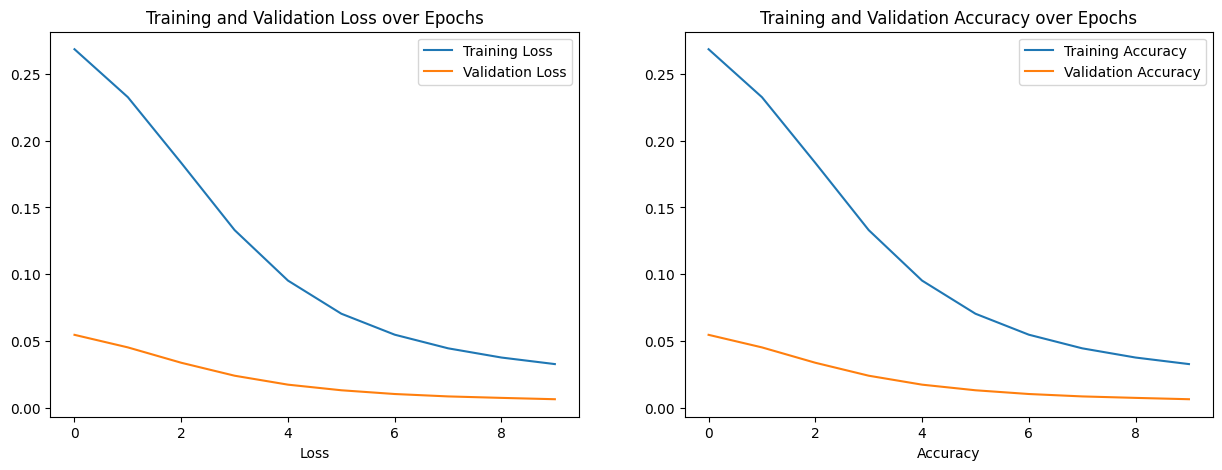

In [29]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(15,5))
ax[0].plot(total_training_loss_plot,label='Training Loss')
ax[0].plot(total_validation_loss_plot,label='Validation Loss')
ax[0].set_title('Training and Validation Loss over Epochs')
ax[0].set_xlabel('Epochs')
ax[0].set_xlabel('Loss')
ax[0].legend()

ax[1].plot(total_training_loss_plot,label='Training Accuracy')
ax[1].plot(total_validation_loss_plot,label='Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy over Epochs')
ax[1].set_xlabel('Epochs')
ax[1].set_xlabel('Accuracy')
ax[1].legend()

plt.show()

Based on the plots there is no clear evidence of significant overfitting in the model. Here's why:

Loss vs. Epochs: For a model to be overfitting, you would typically see the validation loss start to increase or flatten out while the training loss continues to decrease. In your "Loss vs Epochs" plot, both training loss (blue line) and validation loss (orange line) decrease rapidly and then stabilize at very low values. Notably, the validation loss appears to be consistently lower than the training loss in the later epochs (e.g., training loss is around 0.01-0.02 and validation loss is around 0.00 as per the printed values, although this might be due to rounding very small numbers).

Training Accuracy vs. Validation Accuracy: In the "Training Accuracy vs Validation Accuracy" plot, both lines quickly rise to a very high level (around 98-99%) and track each other very closely throughout the training. If overfitting were present, you would expect the training accuracy to continue climbing (or stay very high) while the validation accuracy would flatten or begin to drop. Your validation accuracy often matches or even slightly exceeds the training accuracy, which is a strong indicator of good generalization.

Possible reasons why validation metrics might sometimes be better than training metrics:

Regularization/Dropout: If regularization techniques like dropout are applied during training but not during validation (which is typical when model.eval() is used), the training set effectively sees a more 'difficult' version of the model, leading to higher training loss and lower accuracy compared to validation.
Dataset Characteristics: It's possible the validation dataset is slightly 'easier' for the model to learn than the training dataset.
Overall, the model appears to be learning well and generalizing effectively to unseen data.

# Running inference on the Model in Production Style

In [25]:
df_copy.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')

In [30]:
Area = 223/df_copy['Area'].abs().max()
MajorAxisLength = 81/df_copy['MajorAxisLength'].abs().max()
MinorAxisLength = 42/df_copy['MinorAxisLength'].abs().max()
Eccentricity	= 65 /df_copy['Eccentricity'].abs().max()
ConvexArea = 12 /df_copy['ConvexArea'].abs().max()
EquivDiameter = 33 /df_copy['EquivDiameter'].abs().max()
Extent = 98 /df_copy['Extent'].abs().max()
Perimeter =	97 /df_copy['Perimeter'].abs().max()
Roundness =	67 /df_copy['Roundness'].abs().max()
AspectRation = 24 /df_copy['AspectRation'].abs().max()

test_data = torch.tensor([Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation],dtype=torch.float32).to(device)


predictions = model(test_data)
predictions.item()

1.0